<a href="https://colab.research.google.com/github/harshitgoswami1/colabNotebooks/blob/main/networkIntrusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Network Intrusion Detection with Random Forest

**Author:** *Your Name*  
**Dataset:** [CICIDS2017 — Network Intrusion Dataset](https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset) (Kaggle)  
**Model:** Random Forest Classifier  

---

## Overview

Network intrusion detection is a critical component of modern cybersecurity infrastructure. This project builds a **supervised machine learning classifier** capable of distinguishing between benign network traffic and DDoS attacks using the CICIDS2017 dataset — one of the most widely cited benchmark datasets in network security research.

### Pipeline

```
Data Ingestion → Cleaning & Preprocessing → EDA → Feature Engineering → Model Training → Evaluation
```

### Sections
1. [Setup & Imports](#1-setup--imports)
2. [Data Ingestion](#2-data-ingestion)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Data Cleaning & Preprocessing](#4-data-cleaning--preprocessing)
5. [Feature Engineering](#5-feature-engineering)
6. [Model Training](#6-model-training)
7. [Evaluation & Results](#7-evaluation--results)

---
## 1. Setup & Imports

Install and import all required libraries. We use `kagglehub` to download the dataset directly, and `scikit-learn` for the machine learning pipeline.

In [21]:
# Install dependencies (only needed once)
!pip install kagglehub[pandas-datasets] --quiet

In [22]:
import os
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Dataset download
import kagglehub

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Data Ingestion

We download the **CICIDS2017** dataset via `kagglehub` and load the Friday afternoon DDoS capture file. This file contains both benign traffic and DDoS attack traffic recorded during controlled lab conditions.

In [23]:
# ── Download dataset from Kaggle ──────────────────────────────────────────────
DATA_FILE = "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

print("Available files in dataset:")
for f in os.listdir(path):
    print(f"  • {f}")

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Available files in dataset:
  • Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  • Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  • Tuesday-WorkingHours.pcap_ISCX.csv
  • Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  • Monday-WorkingHours.pcap_ISCX.csv
  • Friday-WorkingHours-Morning.pcap_ISCX.csv
  • Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  • Wednesday-workingHours.pcap_ISCX.csv


In [24]:
# ── Load the DDoS capture file ────────────────────────────────────────────────
df = pd.read_csv(os.path.join(path, DATA_FILE))

# Strip any leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 225,745 rows × 79 columns


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


---
## 3. Exploratory Data Analysis

Before touching the data, we take stock of what we have — class distribution, data types, and any obvious data quality issues.

In [25]:
# ── Basic dataset info ────────────────────────────────────────────────────────
print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
print("Missing values per column (top 10):")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(10) if missing.any() else "  None found.")
print()
print("Infinite values per column:")
inf_counts = np.isinf(df.select_dtypes(include=np.number)).sum().sort_values(ascending=False)
print(inf_counts[inf_counts > 0] if inf_counts.any() else "  None found.")

DATASET SUMMARY
  Rows    : 225,745
  Columns : 79
  Memory  : 153.0 MB

Missing values per column (top 10):
Flow Bytes/s    4
dtype: int64

Infinite values per column:
Flow Packets/s    34
Flow Bytes/s      30
dtype: int64


In [26]:
# ── Class distribution ────────────────────────────────────────────────────────
label_counts = df["Label"].value_counts()

print("Traffic Label Counts:")
print(label_counts.to_string())
print()
print("Class balance (% of total):")
print((label_counts / len(df) * 100).round(2).to_string())

Traffic Label Counts:
Label
DDoS      128027
BENIGN     97718

Class balance (% of total):
Label
DDoS      56.71
BENIGN    43.29


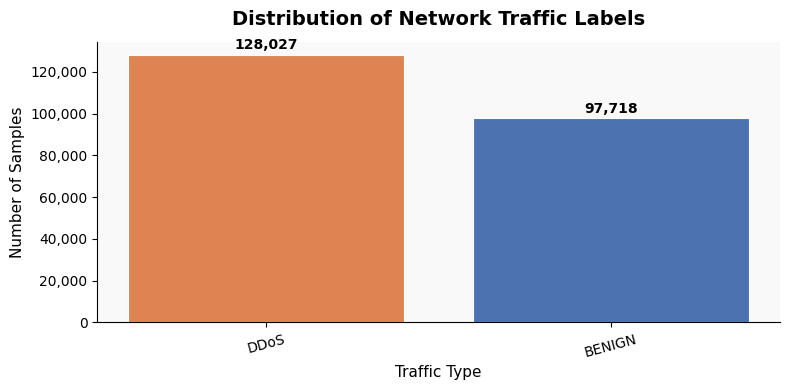

In [27]:
# ── Visualise class distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

colors = ["#4C72B0" if label == "BENIGN" else "#DD8452" for label in label_counts.index]
bars = ax.bar(label_counts.index, label_counts.values, color=colors, edgecolor="white", linewidth=0.8)

# Annotate bars
for bar, count in zip(bars, label_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + label_counts.max() * 0.01,
        f"{count:,}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title("Distribution of Network Traffic Labels", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Traffic Type", fontsize=11)
ax.set_ylabel("Number of Samples", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", rotation=15)
ax.spines[["top", "right"]].set_visible(False)
ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.show()

---
## 4. Data Cleaning & Preprocessing

Network flow data frequently contains `inf` values (e.g. from division-by-zero in packet rate calculations) and `NaN` entries. We replace infinite values with `NaN` and then drop any rows that contain missing data.

In [28]:
rows_before = len(df)

# Replace ±inf with NaN, then drop all NaN rows
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

rows_after = len(df)
dropped = rows_before - rows_after

print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows after cleaning  : {rows_after:,}")
print(f"Rows dropped         : {dropped:,} ({dropped / rows_before * 100:.2f}%)")

Rows before cleaning : 225,745
Rows after cleaning  : 225,711
Rows dropped         : 34 (0.02%)


---
## 5. Feature Engineering

We separate features (`X`) from the target label (`y`) and encode the categorical labels as integers using `LabelEncoder`. The data is then split into training and test sets with an 80/20 ratio.

In [29]:
# ── Separate features and target ──────────────────────────────────────────────
X = df.drop("Label", axis=1)
y = df["Label"]

print(f"Feature matrix : {X.shape[0]:,} samples × {X.shape[1]} features")
print(f"Target vector  : {len(y):,} labels")

Feature matrix : 225,711 samples × 78 features
Target vector  : 225,711 labels


In [30]:
# ── Encode target labels ──────────────────────────────────────────────────────
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Encoded classes:")
for idx, cls in enumerate(encoder.classes_):
    print(f"  {idx}  →  {cls}")

Encoded classes:
  0  →  BENIGN
  1  →  DDoS


In [31]:
# ── Train / test split ────────────────────────────────────────────────────────
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_encoded,         # preserve class ratio in both splits
)

print(f"Training set : {X_train.shape[0]:,} samples ({(1 - TEST_SIZE)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]:,} samples ({TEST_SIZE*100:.0f}%)")

Training set : 180,568 samples (80%)
Test set     : 45,143 samples (20%)


---
## 6. Model Training

We train a **Random Forest** classifier — an ensemble of decision trees that is robust to noisy features, handles class imbalance reasonably well, and is interpretable via feature importances.

| Hyperparameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 100 | Good balance of accuracy vs. training time |
| `random_state` | 42 | Reproducibility |
| `n_jobs` | -1 | Parallelise across all available CPU cores |

In [32]:
# ── Train Random Forest ───────────────────────────────────────────────────────
model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training model...")
model.fit(X_train, y_train)
print("Training complete.")

Training model...
Training complete.


---
## 7. Evaluation & Results

We evaluate the model on the held-out test set using accuracy, a full classification report (precision, recall, F1), and a confusion matrix visualisation.

In [33]:
# ── Generate predictions ──────────────────────────────────────────────────────
y_pred = model.predict(X_test)

In [34]:
# ── Accuracy & Classification Report ─────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)

print("=" * 55)
print(f"  ACCURACY : {acc * 100:.4f}%")
print("=" * 55)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

  ACCURACY : 99.9889%

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



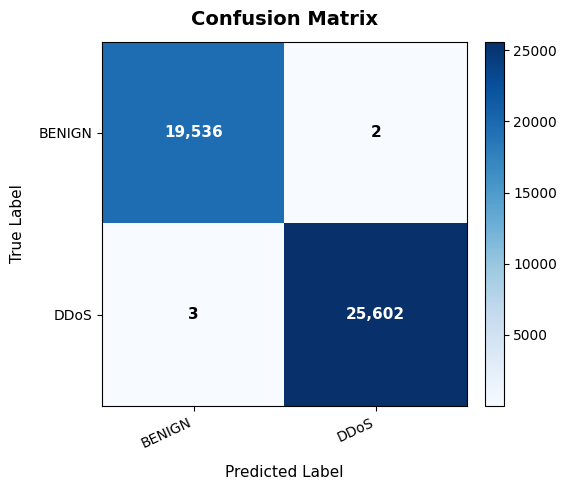

In [35]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Annotate cells
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, f"{cm[i, j]:,}",
            ha="center", va="center", fontsize=11, fontweight="bold",
            color="white" if cm[i, j] > thresh else "black"
        )

ax.set_xticks(range(len(encoder.classes_)))
ax.set_yticks(range(len(encoder.classes_)))
ax.set_xticklabels(encoder.classes_, rotation=25, ha="right", fontsize=10)
ax.set_yticklabels(encoder.classes_, fontsize=10)
ax.set_xlabel("Predicted Label", fontsize=11, labelpad=10)
ax.set_ylabel("True Label", fontsize=11, labelpad=10)
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

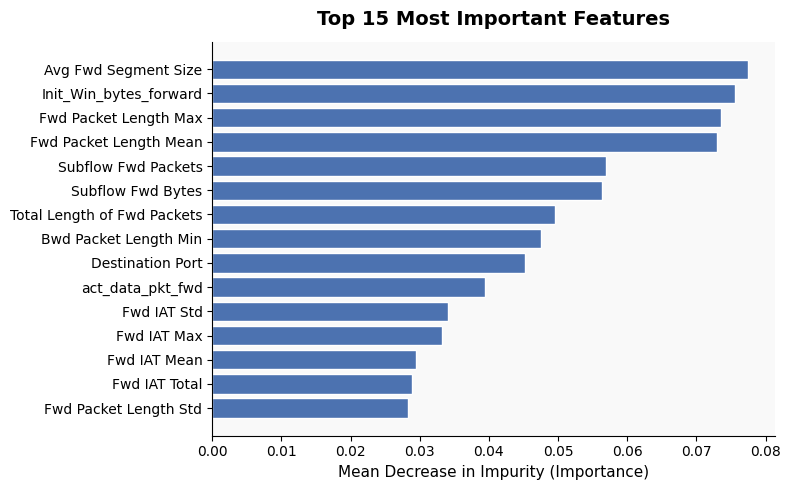

In [36]:
# ── Top 15 Feature Importances ────────────────────────────────────────────────
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top_features.index, top_features.values, color="#4C72B0", edgecolor="white")

ax.set_xlabel("Mean Decrease in Impurity (Importance)", fontsize=11)
ax.set_title("Top 15 Most Important Features", fontsize=14, fontweight="bold", pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.show()